# Step 2 — System Anomaly 偵測

**目標**：找出系統層面的異常（device timeout、DB lock、queue stuck）

**修改下方 PARAMS cell 的參數後，Run All Cells**

In [1]:
# ===== 共用參數 =====
exec(open('../config/params.py').read())
# ==============================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
REPORTS_DIR = Path('../reports')

df = pd.read_csv(DATA_PATH)
df['order_created_at'] = pd.to_datetime(df['order_created_at'], format=DATETIME_FORMAT)

usr_flags = pd.read_csv('../data/user_anomaly_flags.csv')
df = df.merge(usr_flags, on='order_id')

print(f"Total: {len(df):,}, User contention: {df['is_user_anomaly'].sum():,}")


Total: 30,000, User contention: 3


## Queue Stuck 閾值推導

In [3]:
non_contention = df[~df['is_user_anomaly']]
queue_threshold = non_contention['queue_duration_seconds'].quantile(QUEUE_STUCK_PERCENTILE / 100)
print(f"Queue stuck threshold (P{QUEUE_STUCK_PERCENTILE} of non-contention): {queue_threshold:.0f}s")
print(f"Queue max: {df['queue_duration_seconds'].max()}s")

queue_stuck_count = (non_contention['queue_duration_seconds'] > queue_threshold).sum()
print(f"Orders > threshold: {queue_stuck_count}")

if queue_threshold < 120 and df['queue_duration_seconds'].max() < 300:
    print(f"\nℹ️  Queue duration 很小 (max={df['queue_duration_seconds'].max()}s)，可能不存在 queue stuck 問題")


Queue stuck threshold (P99.0 of non-contention): 27s
Queue max: 85.8s
Orders > threshold: 299

ℹ️  Queue duration 很小 (max=85.8s)，可能不存在 queue stuck 問題


## Per-Device IQR: Device Timeout + DB Lock

In [4]:
# === 三層 Hierarchical Threshold ===
# Layer 1: per-device IQR (devices with >= MIN_ORDERS_PER_DEVICE orders)
# Layer 2: per-model IQR (fallback for low-count devices, model has >= MIN_ORDERS_PER_MODEL)
# Layer 3: global P99 (fallback for the rest)

device_order_counts = non_contention.groupby('device_id').size()

# --- Layer 1: Per-device ---
enough_devices = device_order_counts[device_order_counts >= MIN_ORDERS_PER_DEVICE].index
device_data = non_contention[non_contention['device_id'].isin(enough_devices)]

device_thresholds = device_data.groupby('device_id').agg(
    dev_q1=('device_duration_avg_seconds', lambda x: x.quantile(0.25)),
    dev_q3=('device_duration_avg_seconds', lambda x: x.quantile(0.75)),
    db_q1=('db_duration_avg_seconds', lambda x: x.quantile(0.25)),
    db_q3=('db_duration_avg_seconds', lambda x: x.quantile(0.75)),
).reset_index()
device_thresholds['upper_device'] = device_thresholds['dev_q3'] + IQR_MULTIPLIER * (device_thresholds['dev_q3'] - device_thresholds['dev_q1'])
device_thresholds['upper_db'] = device_thresholds['db_q3'] + IQR_MULTIPLIER * (device_thresholds['db_q3'] - device_thresholds['db_q1'])
device_thresholds['threshold_source'] = 'per-device'

# --- Layer 2: Per-model ---
low_count_devices = device_order_counts[device_order_counts < MIN_ORDERS_PER_DEVICE].index
low_count_data = non_contention[non_contention['device_id'].isin(low_count_devices)]

# non_contention already has device_mode_name
low_count_with_model = low_count_data.dropna(subset=['device_mode_name'])

model_order_counts = low_count_with_model.groupby('device_mode_name').size()
enough_models = model_order_counts[model_order_counts >= MIN_ORDERS_PER_MODEL].index

model_thresholds = low_count_with_model[low_count_with_model['device_mode_name'].isin(enough_models)].groupby('device_mode_name').agg(
    dev_q1=('device_duration_avg_seconds', lambda x: x.quantile(0.25)),
    dev_q3=('device_duration_avg_seconds', lambda x: x.quantile(0.75)),
    db_q1=('db_duration_avg_seconds', lambda x: x.quantile(0.25)),
    db_q3=('db_duration_avg_seconds', lambda x: x.quantile(0.75)),
).reset_index()
model_thresholds['upper_device'] = model_thresholds['dev_q3'] + IQR_MULTIPLIER * (model_thresholds['dev_q3'] - model_thresholds['dev_q1'])
model_thresholds['upper_db'] = model_thresholds['db_q3'] + IQR_MULTIPLIER * (model_thresholds['db_q3'] - model_thresholds['db_q1'])

# Map model thresholds to devices
device_to_model = low_count_data[['device_id', 'device_mode_name']].drop_duplicates()
model_device_map = device_to_model[device_to_model['device_mode_name'].isin(enough_models)].dropna()
model_device_thresholds = model_device_map.merge(model_thresholds, on='device_mode_name')[
    ['device_id', 'upper_device', 'upper_db']].copy()
model_device_thresholds['threshold_source'] = 'per-model'

# --- Layer 3: Global P99 ---
global_upper_device = non_contention['device_duration_avg_seconds'].quantile(0.99)
global_upper_db = non_contention['db_duration_avg_seconds'].quantile(0.99)

covered_devices = set(device_thresholds['device_id']) | set(model_device_thresholds['device_id'])
all_devices = set(df['device_id'].unique())
global_devices = all_devices - covered_devices

global_device_thresholds = pd.DataFrame({
    'device_id': list(global_devices),
    'upper_device': global_upper_device,
    'upper_db': global_upper_db,
    'threshold_source': 'global'
})

# --- Combine all thresholds ---
all_thresholds = pd.concat([
    device_thresholds[['device_id', 'upper_device', 'upper_db', 'threshold_source']],
    model_device_thresholds,
    global_device_thresholds,
], ignore_index=True)

# Print summary
layer_summary = all_thresholds['threshold_source'].value_counts()
print(f"=== Threshold Assignment ===")
print(f"  per-device (≥{MIN_ORDERS_PER_DEVICE} orders): {layer_summary.get('per-device', 0)} devices")
print(f"  per-model  (≥{MIN_ORDERS_PER_MODEL} orders): {layer_summary.get('per-model', 0)} devices")
print(f"  global P99 (fallback):    {layer_summary.get('global', 0)} devices")
print(f"  Global thresholds: device>{global_upper_device:.0f}s, db>{global_upper_db:.0f}s")

# IQR=0 check (per-device only)
dev_iqr_zero = ((device_thresholds['dev_q3'] - device_thresholds['dev_q1']) == 0).sum()
db_iqr_zero = ((device_thresholds['db_q3'] - device_thresholds['db_q1']) == 0).sum()
print(f"  IQR=0 (per-device): device={dev_iqr_zero}/{len(device_thresholds)}, db={db_iqr_zero}/{len(device_thresholds)}")

# Merge thresholds to main df
df = df.merge(all_thresholds[['device_id', 'upper_device', 'upper_db', 'threshold_source']], on='device_id')

# Flag system anomalies
df['is_system_anomaly'] = (
    ~df['is_user_anomaly'] & (
        (df['queue_duration_seconds'] > queue_threshold) |
        (df['device_duration_avg_seconds'] > df['upper_device']) |
        (df['db_duration_avg_seconds'] > df['upper_db'])
    )
)

anomalies = df[df['is_system_anomaly']]
print(f"\nSystem anomalies: {len(anomalies):,} / {len(df):,} ({100*len(anomalies)/len(df):.1f}%)")
print(f"  by threshold source:")
if len(anomalies) > 0:
    for src, cnt in anomalies['threshold_source'].value_counts().items():
        print(f"    {src}: {cnt}")


=== Threshold Assignment ===
  per-device (≥20 orders): 244 devices
  per-model  (≥30 orders): 1472 devices
  global P99 (fallback):    284 devices
  Global thresholds: device>23s, db>4s
  IQR=0 (per-device): device=0/244, db=9/244

System anomalies: 2,354 / 30,000 (7.8%)
  by threshold source:
    per-model: 1678
    per-device: 564
    global: 112


## 異常分類

In [5]:
# Classify
def classify_anomaly(row):
    reasons = []
    if row['queue_duration_seconds'] > queue_threshold:
        reasons.append('queue_stuck')
    if row['device_duration_avg_seconds'] > row['upper_device']:
        reasons.append('device_timeout')
    if row['db_duration_avg_seconds'] > row['upper_db']:
        reasons.append('db_lock')
    return ', '.join(reasons) if reasons else 'unknown'

anomalies = anomalies.copy()
anomalies['anomaly_type'] = anomalies.apply(classify_anomaly, axis=1)

print("Anomaly type breakdown:")
type_counts = anomalies['anomaly_type'].str.split(', ').explode().value_counts()
for t, c in type_counts.items():
    print(f"  {t}: {c}")


# Assign anomaly_type to ALL orders
def get_order_label(row):
    if row['is_user_anomaly']:
        return 'user_contention'
    if not row['is_system_anomaly']:
        return 'normal'
    reasons = []
    if row['queue_duration_seconds'] > queue_threshold:
        reasons.append('queue_stuck')
    if row['device_duration_avg_seconds'] > row['upper_device']:
        reasons.append('device_timeout')
    if row['db_duration_avg_seconds'] > row['upper_db']:
        reasons.append('db_lock')
    return ', '.join(reasons) if reasons else 'unknown'

df['anomaly_type'] = df.apply(get_order_label, axis=1)


Anomaly type breakdown:
  db_lock: 1234
  device_timeout: 880
  queue_stuck: 299


## 圖表

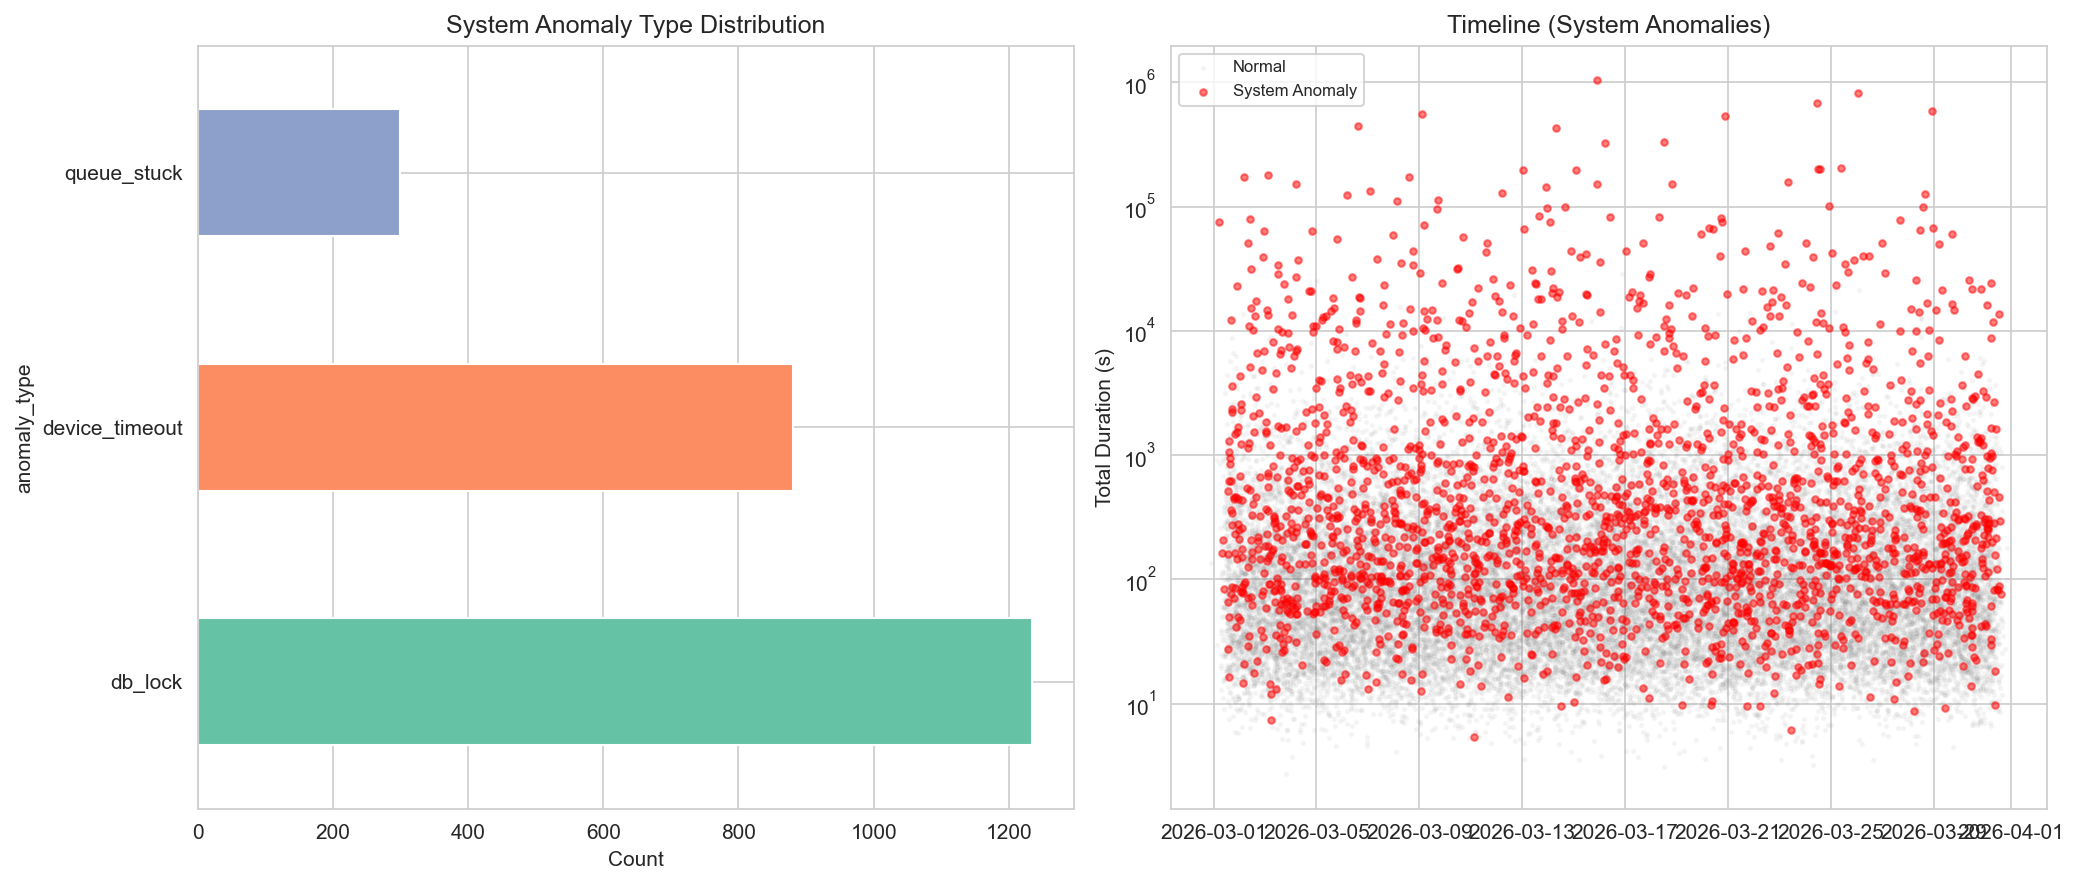

In [6]:
# Chart 1: Anomaly type + dominant phase
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

type_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('System Anomaly Type Distribution')
axes[0].set_xlabel('Count')

# Timeline
ax = axes[1]
normal = df[~df['is_system_anomaly'] & ~df['is_user_anomaly']]
ax.scatter(normal['order_created_at'], normal['total_duration_seconds'],
           alpha=0.05, s=3, color='gray', label='Normal')
ax.scatter(anomalies['order_created_at'], anomalies['total_duration_seconds'],
           alpha=0.5, s=10, c='red', label='System Anomaly')
ax.set_title('Timeline (System Anomalies)')
ax.set_ylabel('Total Duration (s)')
ax.set_yscale('log')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step2_system_anomaly.png', dpi=150)
plt.show()


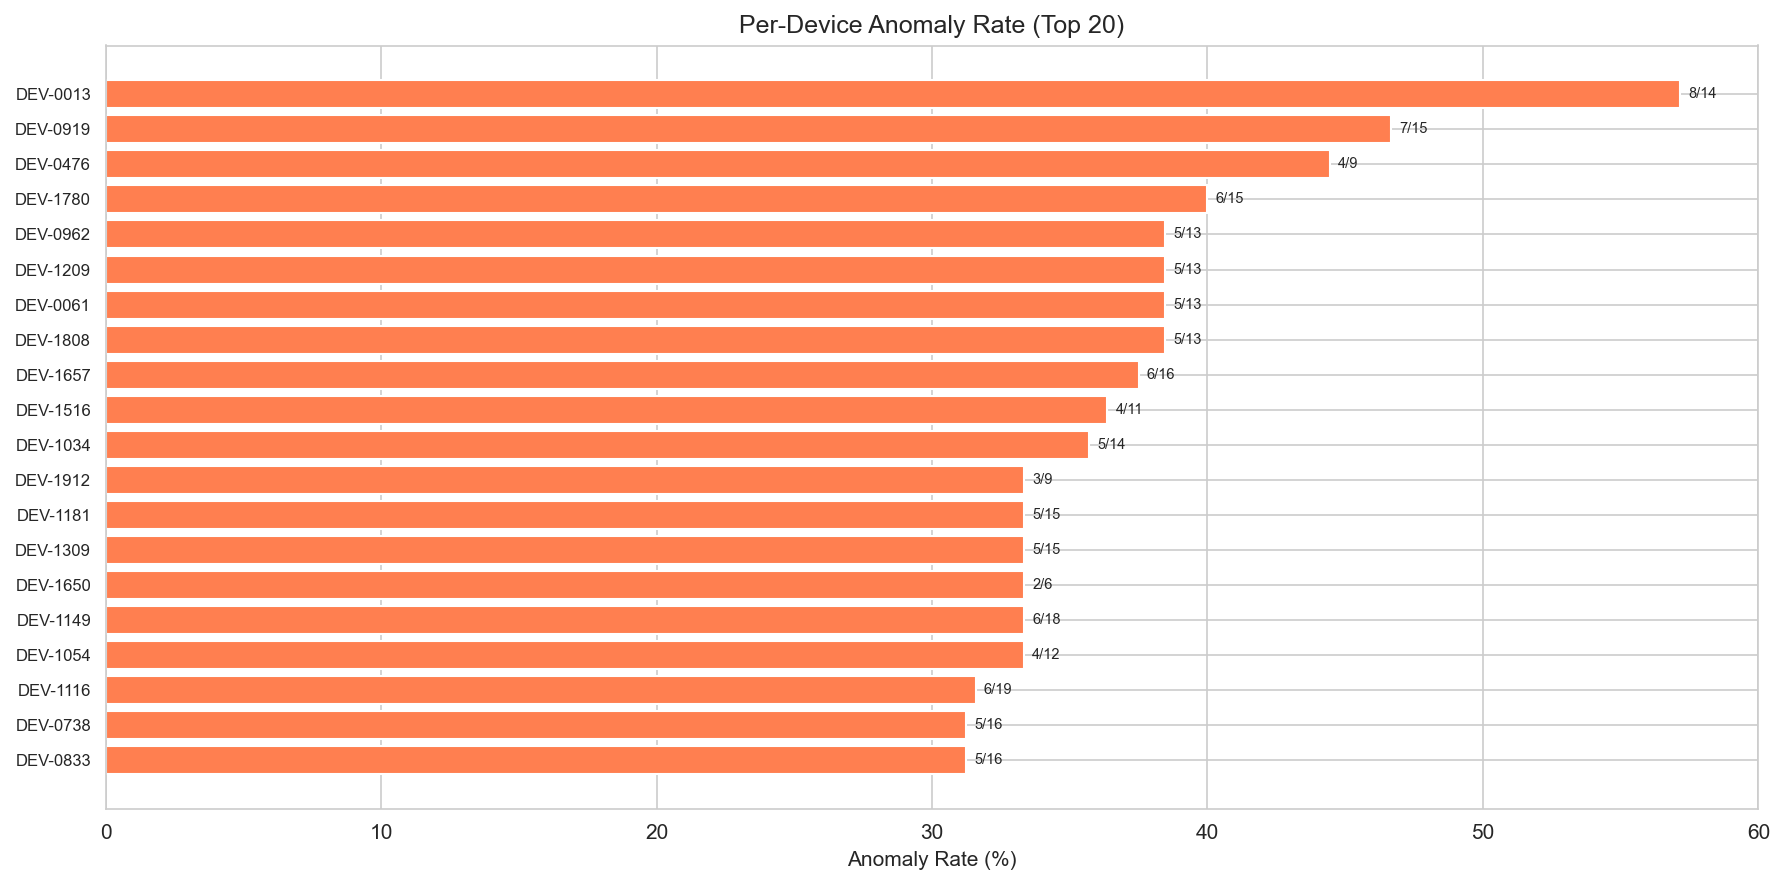

In [7]:
# Per-device anomaly rate (top 20)
dev_anomaly_rate = df.groupby('device_id')['is_system_anomaly'].agg(['mean', 'sum', 'count'])
dev_anomaly_rate = dev_anomaly_rate.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
top20 = dev_anomaly_rate.head(20)
ax.barh(range(len(top20)), top20['mean'] * 100, color='coral')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=8)
ax.set_title('Per-Device Anomaly Rate (Top 20)')
ax.set_xlabel('Anomaly Rate (%)')
ax.invert_yaxis()
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row['mean']*100 + 0.3, i, f'{int(row["sum"])}/{int(row["count"])}', va='center', fontsize=7)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step2_device_anomaly_rate.png', dpi=150)
plt.show()


## 異常按維度分佈

按 location、system、threshold source、時間 切分異常類型。

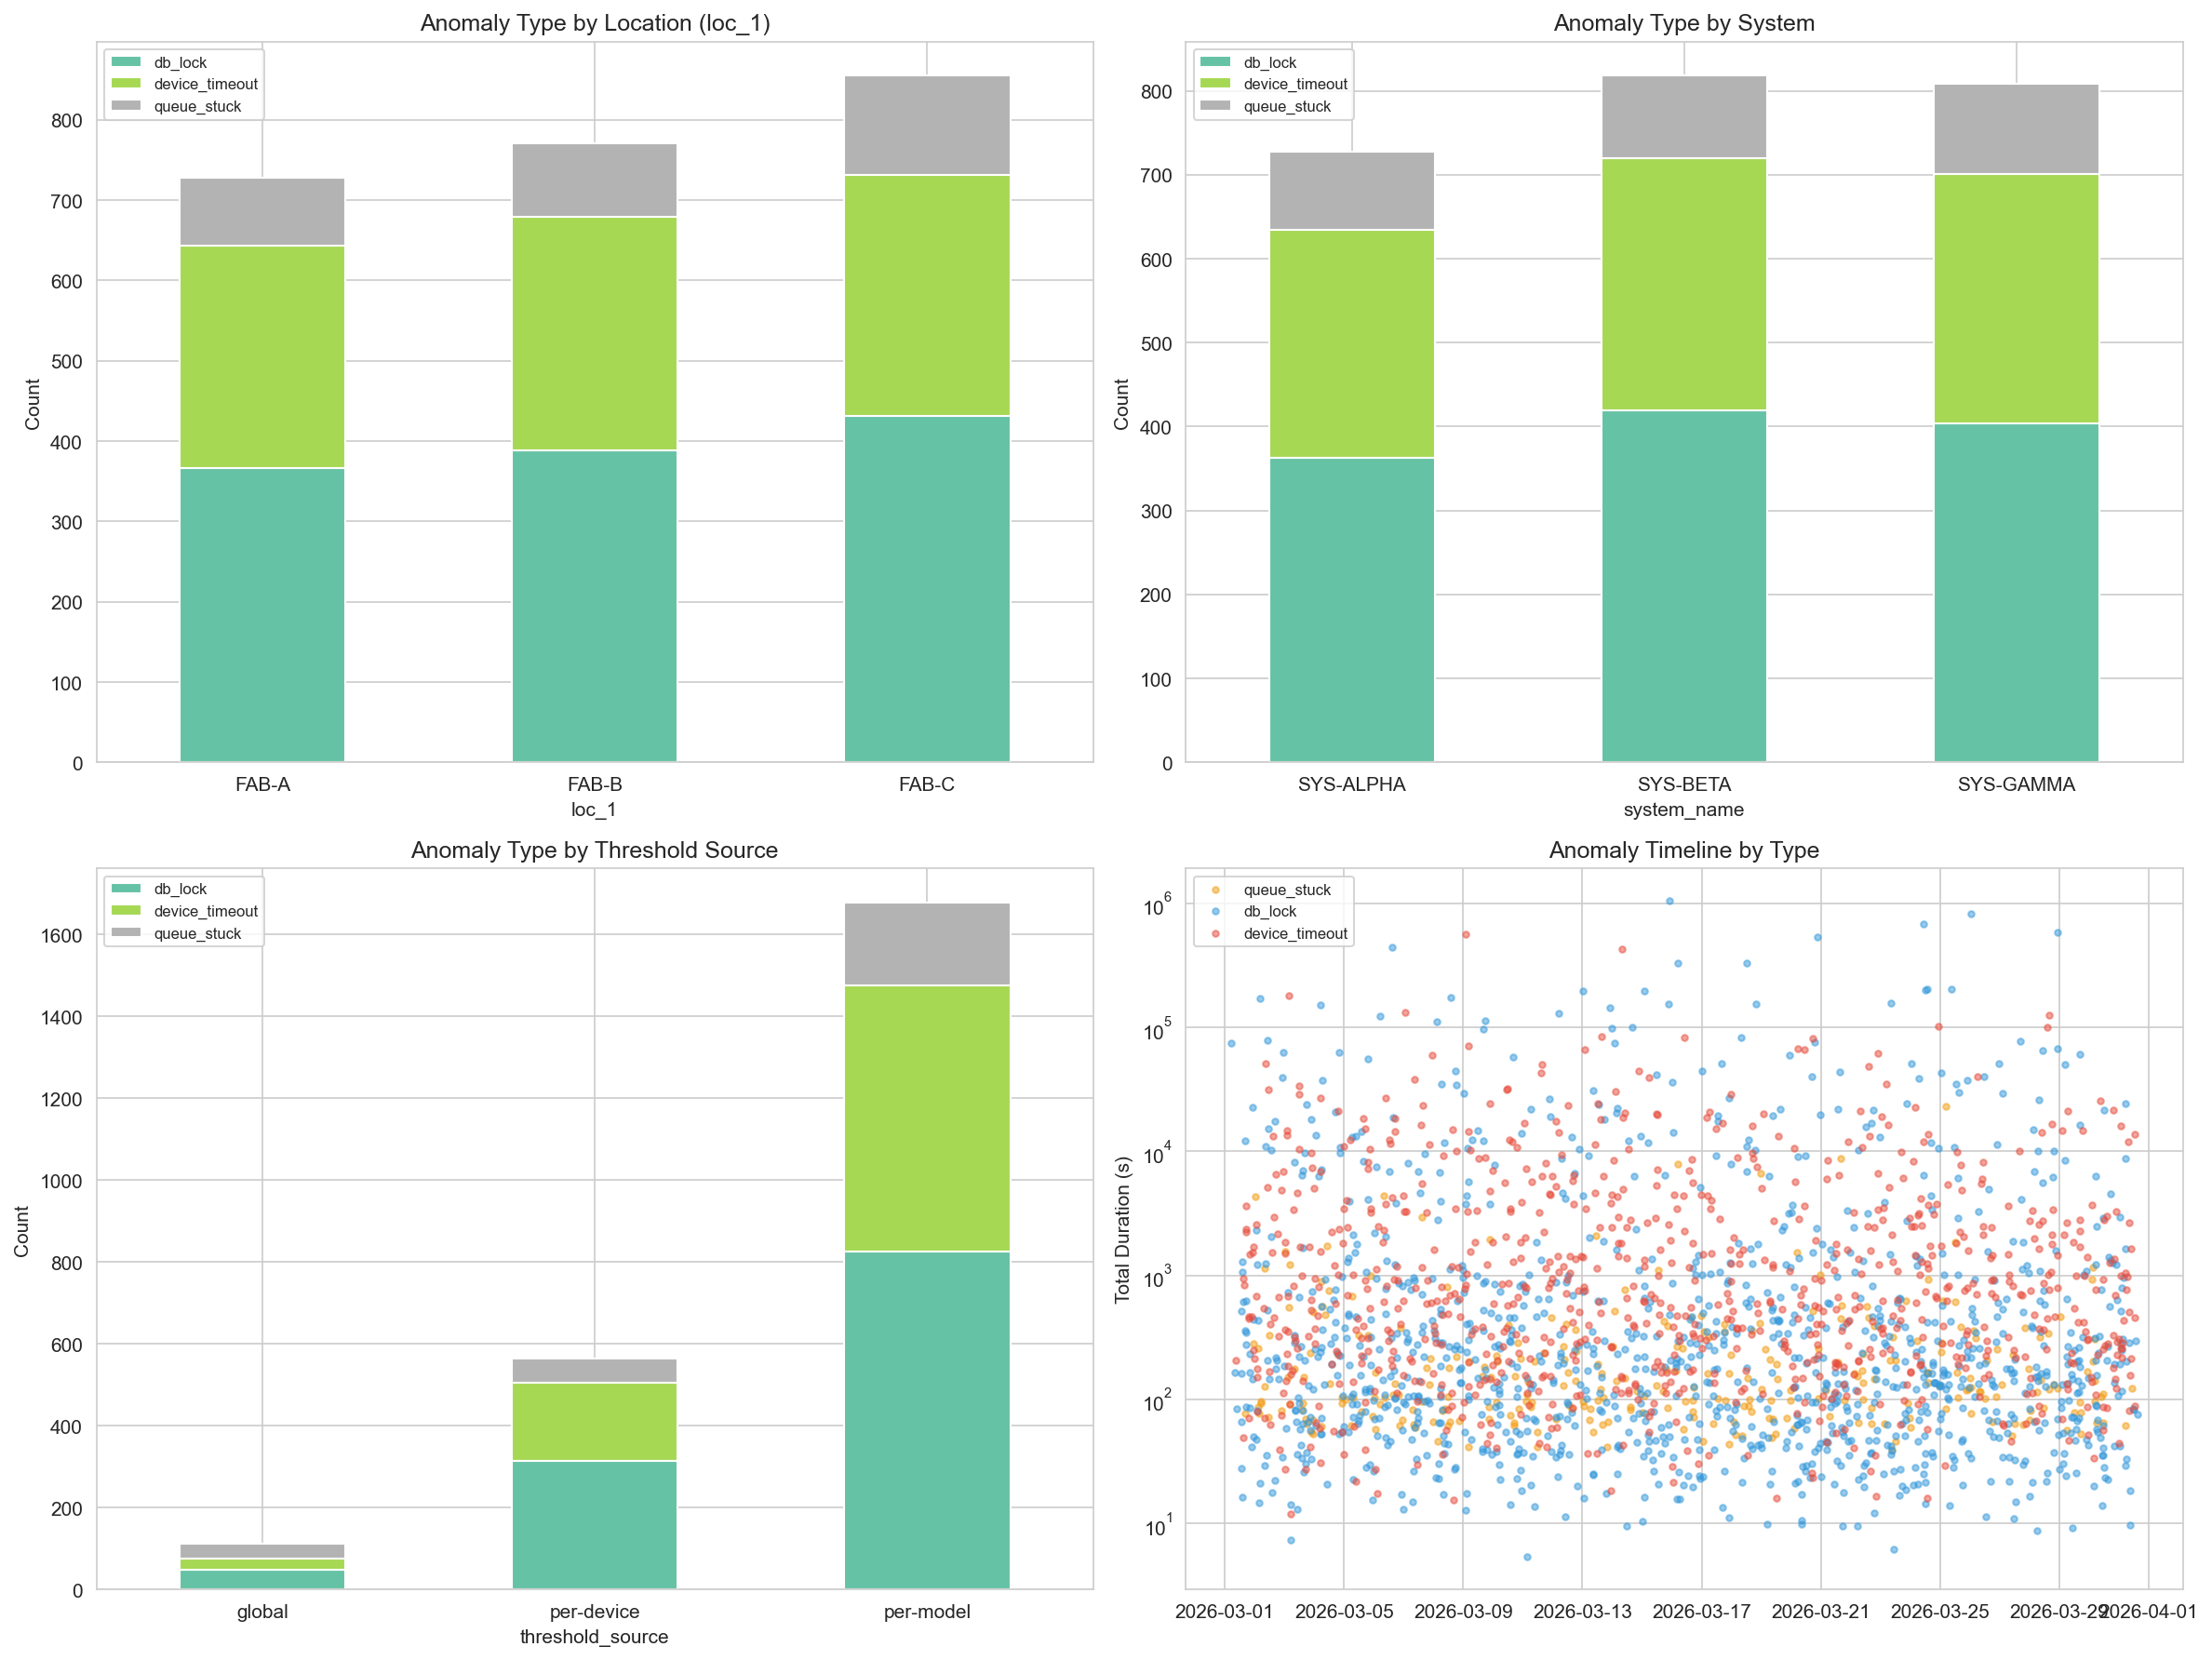

=== Anomaly Label Distribution (all orders) ===
  normal: 27,643 (92.1%)
  db_lock: 1,186 (4.0%)
  device_timeout: 827 (2.8%)
  queue_stuck: 283 (0.9%)
  device_timeout, db_lock: 42 (0.1%)
  queue_stuck, device_timeout: 10 (0.0%)
  queue_stuck, db_lock: 5 (0.0%)
  user_contention: 3 (0.0%)
  queue_stuck, device_timeout, db_lock: 1 (0.0%)


In [8]:
# Anomaly distribution by segment
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# By anomaly_type × loc_1
anom_by_loc = anomalies.groupby(['loc_1', anomalies['anomaly_type'].str.split(', ').str[0]]).size().unstack(fill_value=0)
anom_by_loc.plot(kind='bar', stacked=True, ax=axes[0][0], colormap='Set2')
axes[0][0].set_title('Anomaly Type by Location (loc_1)')
axes[0][0].set_ylabel('Count')
axes[0][0].tick_params(axis='x', rotation=0)
axes[0][0].legend(fontsize=8)

# By anomaly_type × system_name
anom_by_sys = anomalies.groupby(['system_name', anomalies['anomaly_type'].str.split(', ').str[0]]).size().unstack(fill_value=0)
anom_by_sys.plot(kind='bar', stacked=True, ax=axes[0][1], colormap='Set2')
axes[0][1].set_title('Anomaly Type by System')
axes[0][1].set_ylabel('Count')
axes[0][1].tick_params(axis='x', rotation=0)
axes[0][1].legend(fontsize=8)

# By anomaly_type × threshold_source
anom_by_src = anomalies.groupby(['threshold_source', anomalies['anomaly_type'].str.split(', ').str[0]]).size().unstack(fill_value=0)
anom_by_src.plot(kind='bar', stacked=True, ax=axes[1][0], colormap='Set2')
axes[1][0].set_title('Anomaly Type by Threshold Source')
axes[1][0].set_ylabel('Count')
axes[1][0].tick_params(axis='x', rotation=0)
axes[1][0].legend(fontsize=8)

# Timeline by anomaly_type
anom_types = anomalies['anomaly_type'].str.split(', ').str[0]
colors_map = {'device_timeout': '#e74c3c', 'db_lock': '#3498db', 'queue_stuck': '#f39c12'}
for atype in anom_types.unique():
    mask = anom_types == atype
    axes[1][1].scatter(anomalies.loc[mask, 'order_created_at'], 
                       anomalies.loc[mask, 'total_duration_seconds'],
                       alpha=0.5, s=10, label=atype, color=colors_map.get(atype, 'gray'))
axes[1][1].set_title('Anomaly Timeline by Type')
axes[1][1].set_ylabel('Total Duration (s)')
axes[1][1].set_yscale('log')
axes[1][1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step2_anomaly_by_segment.png', dpi=150)
plt.show()

# Label distribution summary
print("=== Anomaly Label Distribution (all orders) ===")
label_dist = df['anomaly_type'].value_counts()
for label, count in label_dist.items():
    print(f"  {label}: {count:,} ({100*count/len(df):.1f}%)")


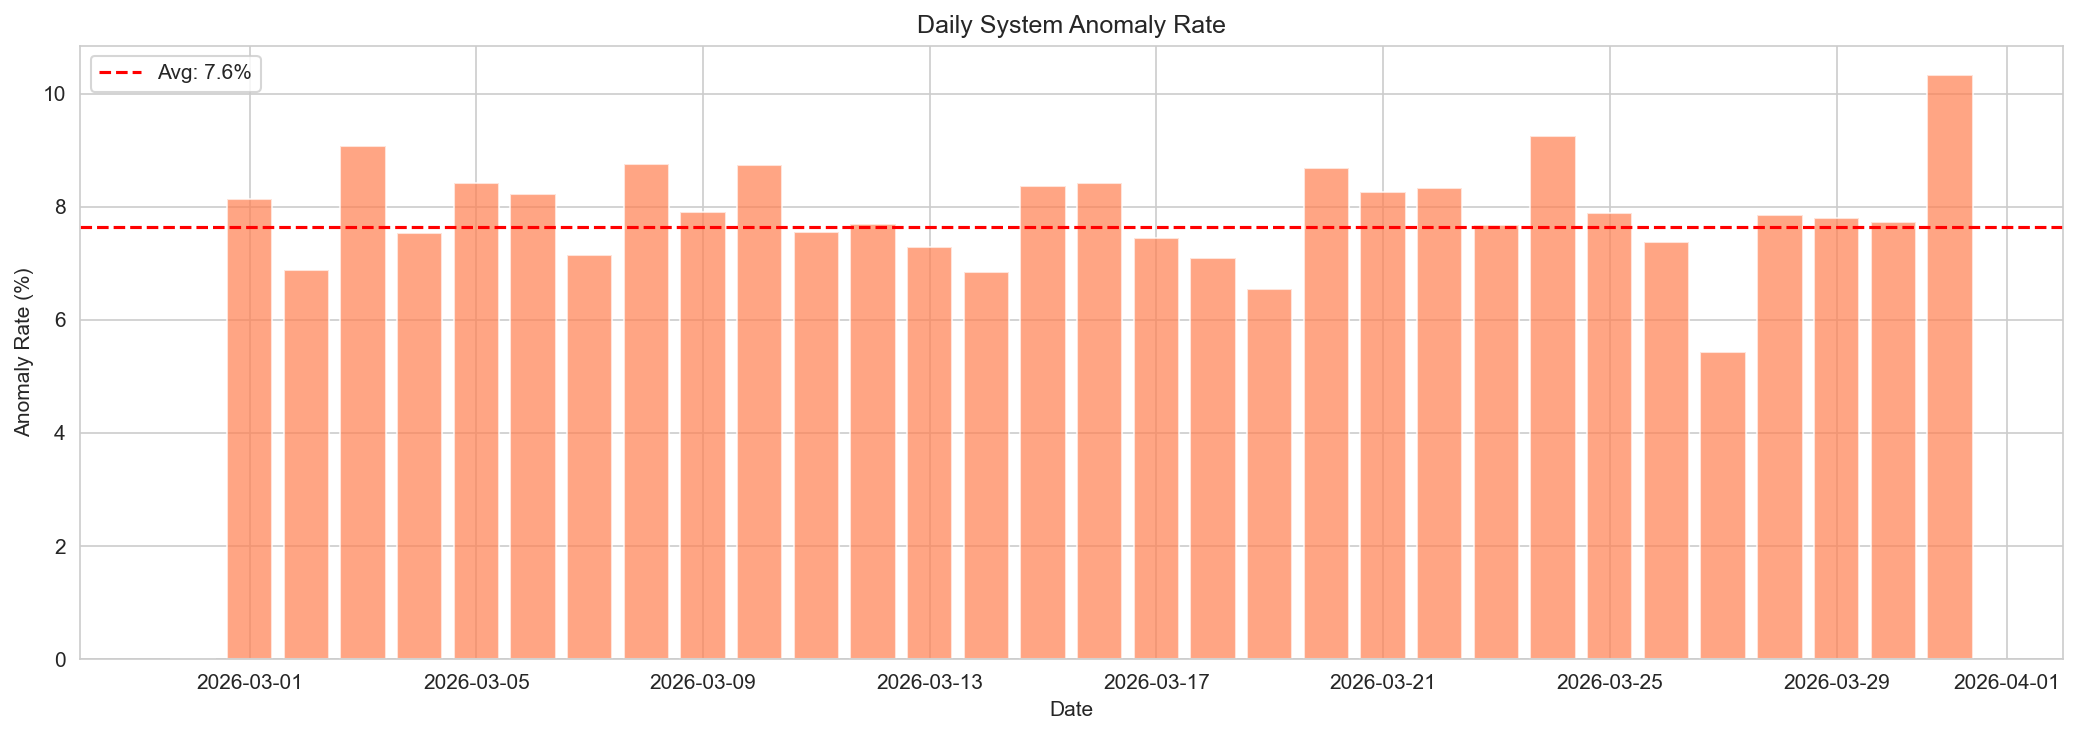

Daily anomaly rate: min=0.0%, max=10.3%, avg=7.6%


In [9]:
# Daily anomaly rate trend
df['date'] = df['order_created_at'].dt.date
daily_anom = df.groupby('date').agg(
    anomaly_rate=('is_system_anomaly', 'mean'),
    total=('order_id', 'count'),
    anomaly_count=('is_system_anomaly', 'sum'),
).reset_index()
daily_anom['date'] = pd.to_datetime(daily_anom['date'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(daily_anom['date'], daily_anom['anomaly_rate'] * 100, color='coral', alpha=0.7, width=0.8)
ax.axhline(y=daily_anom['anomaly_rate'].mean() * 100, color='red', linestyle='--', 
           label=f"Avg: {daily_anom['anomaly_rate'].mean()*100:.1f}%")
ax.set_title('Daily System Anomaly Rate')
ax.set_ylabel('Anomaly Rate (%)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step2_anomaly_trend.png', dpi=150)
plt.show()

print(f"Daily anomaly rate: min={daily_anom['anomaly_rate'].min()*100:.1f}%, max={daily_anom['anomaly_rate'].max()*100:.1f}%, avg={daily_anom['anomaly_rate'].mean()*100:.1f}%")


## 抽查驗證

以下隨機抽 20 筆異常 + 20 筆正常訂單。
請人工確認異常訂單是否合理（duration 明顯偏高），正常訂單是否有漏標。

In [10]:
# 抽查用：隨機抽 20 筆異常 + 20 筆正常，供人工驗證
print("=== 異常訂單抽查樣本（20 筆）===")
sample_cols = ['order_id', 'device_id', 'queue_duration_seconds',
               'device_duration_avg_seconds', 'db_duration_avg_seconds',
               'file_count', 'total_duration_seconds']
if len(anomalies) > 0:
    n_sample = min(20, len(anomalies))
    print(anomalies[sample_cols].sample(n=n_sample, random_state=42).to_string(index=False))
else:
    print("（無異常訂單）")

print("\n=== 正常訂單抽查樣本（20 筆）===")
normal_orders = df[~df['is_system_anomaly'] & ~df['is_user_anomaly']]
if len(normal_orders) > 0:
    n_sample = min(20, len(normal_orders))
    print(normal_orders[sample_cols].sample(n=n_sample, random_state=42).to_string(index=False))


=== 異常訂單抽查樣本（20 筆）===
  order_id device_id  queue_duration_seconds  device_duration_avg_seconds  db_duration_avg_seconds  file_count  total_duration_seconds
ORD-024749  DEV-0757                     0.0                        12.45                     0.00         109                   370.8
ORD-010785  DEV-1844                     0.0                         1.82                     1.05         178                   148.2
ORD-016268  DEV-1483                    53.8                         1.20                     0.00         692                   307.1
ORD-011500  DEV-0255                     0.0                         2.25                     1.04         111                   151.4
ORD-009694  DEV-0494                     1.9                        20.47                     0.00         238                  1244.0
ORD-007198  DEV-1479                    38.7                         1.30                     0.00         150                    92.7
ORD-029829  DEV-1291             

## 匯出

In [11]:
anomaly_flags = df[['order_id', 'is_system_anomaly', 'anomaly_type']].copy()
anomaly_flags.to_csv('../data/system_anomaly_flags.csv', index=False)
print(f"Exported: data/system_anomaly_flags.csv ({anomaly_flags['is_system_anomaly'].sum():,} anomalies)")

print(f"\n=== Step 2 Summary ===")
print(f"Params: IQR_MULTIPLIER={IQR_MULTIPLIER}, QUEUE_STUCK_PERCENTILE=P{QUEUE_STUCK_PERCENTILE}")
print(f"Queue stuck threshold: {queue_threshold:.0f}s")
print(f"System anomalies: {len(anomalies):,} ({100*len(anomalies)/len(df):.1f}%)")
for t, c in type_counts.items():
    print(f"  {t}: {c}")
print(f"IQR=0 devices: device={dev_iqr_zero}, db={db_iqr_zero}")


Exported: data/system_anomaly_flags.csv (2,354 anomalies)

=== Step 2 Summary ===
Params: IQR_MULTIPLIER=3, QUEUE_STUCK_PERCENTILE=P99.0
Queue stuck threshold: 27s
System anomalies: 2,354 (7.8%)
  db_lock: 1234
  device_timeout: 880
  queue_stuck: 299
IQR=0 devices: device=0, db=9


In [12]:
# Export summary to reports/
summary = []
summary.append("=" * 60)
summary.append("Step 2 — System Anomaly")
summary.append("=" * 60)
summary.append(f"\n--- 參數 ---")
summary.append(f"IQR_MULTIPLIER={IQR_MULTIPLIER}  （Q3 + N×IQR 的 N，越大越嚴格，越少異常）")
summary.append(f"QUEUE_STUCK_PERCENTILE=P{QUEUE_STUCK_PERCENTILE}  （queue stuck 取第幾 percentile 為閾值）")
summary.append(f"MIN_ORDERS_PER_DEVICE={MIN_ORDERS_PER_DEVICE}  （device 訂單 ≥ 此值才用 per-device IQR）")
summary.append(f"MIN_ORDERS_PER_MODEL={MIN_ORDERS_PER_MODEL}  （model 訂單 ≥ 此值才用 per-model IQR）")
summary.append(f"Queue stuck threshold: {queue_threshold:.0f}s  （queue 等待超過此秒數視為 queue stuck）")
summary.append(f"\n--- 閾值分配 ---  （每台 device 依訂單數量決定用哪層閾值）")
layer_summary = all_thresholds['threshold_source'].value_counts()
summary.append(f"  per-device: {layer_summary.get('per-device', 0)} devices  （≥{MIN_ORDERS_PER_DEVICE} 筆，用該 device 自己的 IQR）")
summary.append(f"  per-model:  {layer_summary.get('per-model', 0)} devices  （<{MIN_ORDERS_PER_DEVICE} 筆，用同型號的 IQR）")
summary.append(f"  global:     {layer_summary.get('global', 0)} devices  （型號也不夠或為 null，用全域 P99）")
summary.append(f"\n--- 結果 ---")
summary.append(f"System anomalies: {len(anomalies):,} ({100*len(anomalies)/len(df):.1f}%)  （被標記為系統異常的訂單數）")
summary.append(f"\nType breakdown:  （異常類型分佈）")
for t, c in type_counts.items():
    desc = {'queue_stuck': 'queue 等待異常久（consumer 可能卡住）',
            'device_timeout': 'device command 耗時異常久（設備可能有問題）',
            'db_lock': 'DB 查詢異常久（可能有 lock 或 slow query）'}.get(t, '')
    summary.append(f"  {t}: {c}  （{desc}）")

summary.append(f"\n--- 全部訂單 Label 分佈 ---  （含 normal 和 user_contention）")
label_dist = df['anomaly_type'].value_counts()
for label, count in label_dist.items():
    summary.append(f"  {label}: {count:,} ({100*count/len(df):.1f}%)")

with open(str(REPORTS_DIR / 'step2_summary.txt'), 'w') as f:
    f.write('\n'.join(summary))
print(f"Saved: reports/step2_summary.txt")


Saved: reports/step2_summary.txt
